<a href="https://www.kaggle.com/code/sonawanelalitsunil/river-plastic-waste-2015-vs-2060-risk-ml-96?scriptVersionId=235625713" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/river-plastic-waste-risk-scenarios-2015-vs-2060/River_Plastic_Waste_Risk_Scenarios_2015_2060.csv


## Title: River Plastic Waste: 2015 vs 2060 Risk outlook

####  Description:
A comparative snapshot of global river plastic-waste risk between 2015 and projected 2060 scenarios, highlighting shifts in pollution hotspots and future environmental challenges.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/river-plastic-waste-risk-scenarios-2015-vs-2060/River_Plastic_Waste_Risk_Scenarios_2015_2060.csv')

In [3]:
df.head()

,River_ID,River_Name,Country,Continent,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,...,Basin_Area_km2,Urbanization_2015_pct,Urbanization_2060_pct,GDP_per_capita_2015,GDP_per_capita_2060,Policy_Strength_2015,Policy_Strength_2060,Waste_Collection_Rate_2015,Waste_Collection_Rate_2060,Risk_Score_Change
0,1,River_0,Brazil,South America,16194478,26111907,17792.200652,19741.088429,2334.317226,3190.490009,...,416388.877759,32.740347,40.467721,4993.410491,7967.060920,0.524756,0.797534,0.403860,0.606824,-393.971968
1,2,River_1,Vietnam,Asia,13337723,23762872,9773.501161,16410.792306,2186.109392,3716.919707,...,7619.215619,76.532105,89.981429,9942.704312,12137.617217,0.230894,0.427304,0.678284,0.880784,-226.234377
2,3,River_2,USA,North America,13579854,16585826,12100.472956,12974.031643,3038.093359,3049.301900,...,198179.967765,75.599532,91.508612,8500.248836,16503.889051,0.520834,1.000000,0.791174,1.000000,211.992452
3,4,River_3,DR Congo,Africa,2804238,4711445,2402.540235,4150.474491,501.023859,739.551654,...,3755.536445,68.927686,84.530546,18360.675617,40442.168783,0.074045,0.317431,0.281108,0.546884,-81.894650
4,5,River_4,Nigeria,Africa,17873323,23800628,10072.660424,21681.951354,1662.358278,6416.149836,...,380631.739260,53.676632,70.241140,12597.992111,23678.589812,0.427541,0.537709,0.275524,0.333381,61.485910


In [4]:
df.tail()

,River_ID,River_Name,Country,Continent,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,...,Basin_Area_km2,Urbanization_2015_pct,Urbanization_2060_pct,GDP_per_capita_2015,GDP_per_capita_2060,Policy_Strength_2015,Policy_Strength_2060,Waste_Collection_Rate_2015,Waste_Collection_Rate_2060,Risk_Score_Change
2995,2996,River_2995,USA,North America,9545462,13014361,6476.751523,12850.149169,1076.331135,4484.504095,...,398338.607527,61.529246,80.449719,1082.223923,1590.380309,0.702033,1.000000,0.686262,0.880132,309.841753
2996,2997,River_2996,Bangladesh,Asia,12539153,15491984,7455.595941,13451.364513,1199.943280,2916.695561,...,7768.820997,75.183617,84.556033,21126.478478,45698.358764,0.114411,0.339703,0.539258,0.654798,48.386442
2997,2998,River_2997,USA,North America,15872486,23641903,9157.180049,15158.263608,2332.159641,3469.830388,...,208084.380223,55.054826,60.780559,23047.151647,31758.844558,0.213366,0.376085,0.548250,0.802464,117.905676
2998,2999,River_2998,Bangladesh,Asia,5674091,8568426,4386.064297,8088.395637,1268.559800,1562.337914,...,383062.750468,57.764784,77.558000,13029.716363,24383.098663,0.249268,0.425637,0.713473,0.856639,-87.542504
2999,3000,River_2999,China,Asia,8144010,13373352,11428.413082,13740.293673,1361.903953,2120.737064,...,356704.162381,64.450851,72.907541,17849.068627,24208.749214,0.101682,0.223775,0.767139,0.884792,46.534596


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   River_ID                    3000 non-null   int64  
 1   River_Name                  3000 non-null   object 
 2   Country                     3000 non-null   object 
 3   Continent                   3000 non-null   object 
 4   Population_2015             3000 non-null   int64  
 5   Population_2060             3000 non-null   int64  
 6   Waste_Generation_2015_tons  3000 non-null   float64
 7   Waste_Generation_2060_tons  3000 non-null   float64
 8   Plastic_Waste_2015_tons     3000 non-null   float64
 9   Plastic_Waste_2060_tons     3000 non-null   float64
 10  Mismanaged_Waste_2015_tons  3000 non-null   float64
 11  Mismanaged_Waste_2060_tons  3000 non-null   float64
 12  Plastic_to_River_2015_tons  3000 non-null   float64
 13  Plastic_to_River_2060_tons  3000 

In [6]:
df.describe()

,River_ID,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,Mismanaged_Waste_2015_tons,Mismanaged_Waste_2060_tons,Plastic_to_River_2015_tons,...,Basin_Area_km2,Urbanization_2015_pct,Urbanization_2060_pct,GDP_per_capita_2015,GDP_per_capita_2060,Policy_Strength_2015,Policy_Strength_2060,Waste_Collection_Rate_2015,Waste_Collection_Rate_2060,Risk_Score_Change
count,3000.000000,3.000000e+03,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,9.902995e+06,1.439333e+07,9937.108593,15722.462520,1972.420450,3944.802205,984.794046,1599.795419,246.130444,...,255050.174161,50.057792,62.708560,12788.280554,23538.089370,0.497450,0.741778,0.553076,0.720815,35.788421
std,866.169729,5.768554e+06,8.701584e+06,6695.912177,10601.295790,1486.016108,2857.043089,792.936969,1292.345791,225.795829,...,145043.553125,17.206687,17.699645,6983.325528,13866.334802,0.287451,0.248651,0.199433,0.200259,280.864915
min,1.000000,1.002450e+05,1.488670e+05,97.433964,112.888574,17.274615,24.166990,7.181986,5.941984,1.340865,...,1224.065038,20.000332,25.893246,521.003622,765.286423,0.000125,0.110998,0.200072,0.256240,-1246.002148
25%,750.750000,4.877241e+06,6.893512e+06,4430.943455,7201.296054,825.059031,1713.877218,369.395386,634.996615,81.662342,...,128174.188742,35.462172,48.265934,6834.986397,11996.601860,0.248929,0.537364,0.385712,0.559278,-78.293886
50%,1500.500000,9.838680e+06,1.410217e+07,9107.858721,14318.548919,1665.601032,3441.779457,797.706275,1297.788773,182.009292,...,257727.765870,49.801801,62.709587,12924.714742,22850.505800,0.492732,0.784064,0.550619,0.733963,6.131354
75%,2250.250000,1.487036e+07,2.103804e+07,14079.641695,22424.598839,2774.576420,5520.531338,1381.727937,2213.311950,340.324187,...,381416.629634,64.783787,76.976344,18927.486649,33499.182090,0.748619,1.000000,0.729408,0.899346,132.037426
max,3000.000000,1.999544e+07,3.526011e+07,29269.926629,54578.093316,8317.527382,15193.460738,4969.205532,8550.722397,1869.833226,...,499450.744236,79.963753,99.299629,24991.072823,60813.487769,0.999501,1.000000,0.899488,1.000000,2036.613754


In [7]:
df.isnull().sum()

River_ID                      0
River_Name                    0
Country                       0
Continent                     0
Population_2015               0
Population_2060               0
Waste_Generation_2015_tons    0
Waste_Generation_2060_tons    0
Plastic_Waste_2015_tons       0
Plastic_Waste_2060_tons       0
Mismanaged_Waste_2015_tons    0
Mismanaged_Waste_2060_tons    0
Plastic_to_River_2015_tons    0
Plastic_to_River_2060_tons    0
River_Length_km               0
Basin_Area_km2                0
Urbanization_2015_pct         0
Urbanization_2060_pct         0
GDP_per_capita_2015           0
GDP_per_capita_2060           0
Policy_Strength_2015          0
Policy_Strength_2060          0
Waste_Collection_Rate_2015    0
Waste_Collection_Rate_2060    0
Risk_Score_Change             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

River_ID                        int64
River_Name                     object
Country                        object
Continent                      object
Population_2015                 int64
Population_2060                 int64
Waste_Generation_2015_tons    float64
Waste_Generation_2060_tons    float64
Plastic_Waste_2015_tons       float64
Plastic_Waste_2060_tons       float64
Mismanaged_Waste_2015_tons    float64
Mismanaged_Waste_2060_tons    float64
Plastic_to_River_2015_tons    float64
Plastic_to_River_2060_tons    float64
River_Length_km               float64
Basin_Area_km2                float64
Urbanization_2015_pct         float64
Urbanization_2060_pct         float64
GDP_per_capita_2015           float64
GDP_per_capita_2060           float64
Policy_Strength_2015          float64
Policy_Strength_2060          float64
Waste_Collection_Rate_2015    float64
Waste_Collection_Rate_2060    float64
Risk_Score_Change             float64
dtype: object

In [10]:
df.shape

(3000, 25)

In [11]:
df.columns

Index(['River_ID', 'River_Name', 'Country', 'Continent', 'Population_2015',
       'Population_2060', 'Waste_Generation_2015_tons',
       'Waste_Generation_2060_tons', 'Plastic_Waste_2015_tons',
       'Plastic_Waste_2060_tons', 'Mismanaged_Waste_2015_tons',
       'Mismanaged_Waste_2060_tons', 'Plastic_to_River_2015_tons',
       'Plastic_to_River_2060_tons', 'River_Length_km', 'Basin_Area_km2',
       'Urbanization_2015_pct', 'Urbanization_2060_pct', 'GDP_per_capita_2015',
       'GDP_per_capita_2060', 'Policy_Strength_2015', 'Policy_Strength_2060',
       'Waste_Collection_Rate_2015', 'Waste_Collection_Rate_2060',
       'Risk_Score_Change'],
      dtype='object')

## Data visualizations

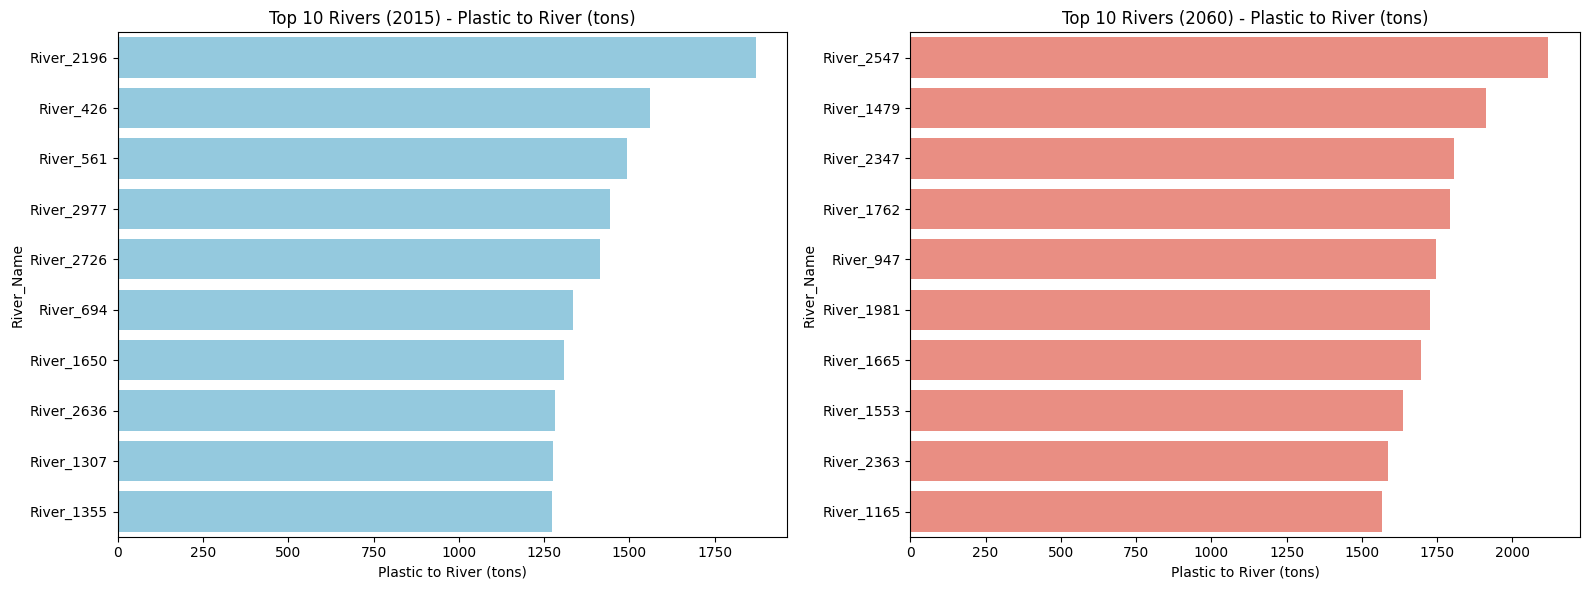

In [12]:
top2015 = df.nlargest(10, 'Plastic_to_River_2015_tons')
top2060 = df.nlargest(10, 'Plastic_to_River_2060_tons')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Plastic_to_River_2015_tons', y='River_Name', data=top2015, ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Rivers (2015) - Plastic to River (tons)')
axes[0].set_xlabel('Plastic to River (tons)')

sns.barplot(x='Plastic_to_River_2060_tons', y='River_Name', data=top2060, ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Rivers (2060) - Plastic to River (tons)')
axes[1].set_xlabel('Plastic to River (tons)')

plt.tight_layout()
plt.show()


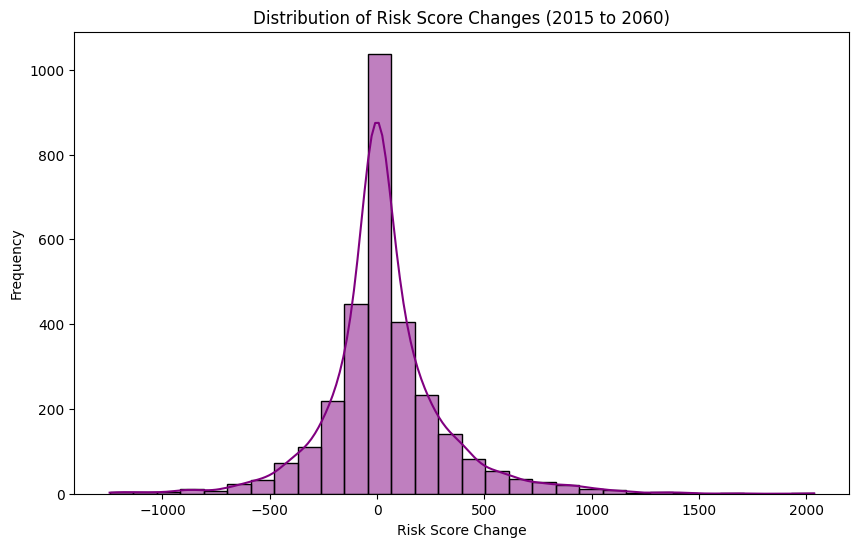

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Risk_Score_Change'], bins=30, kde=True, color='purple')
plt.title('Distribution of Risk Score Changes (2015 to 2060)')
plt.xlabel('Risk Score Change')
plt.ylabel('Frequency')
plt.show()


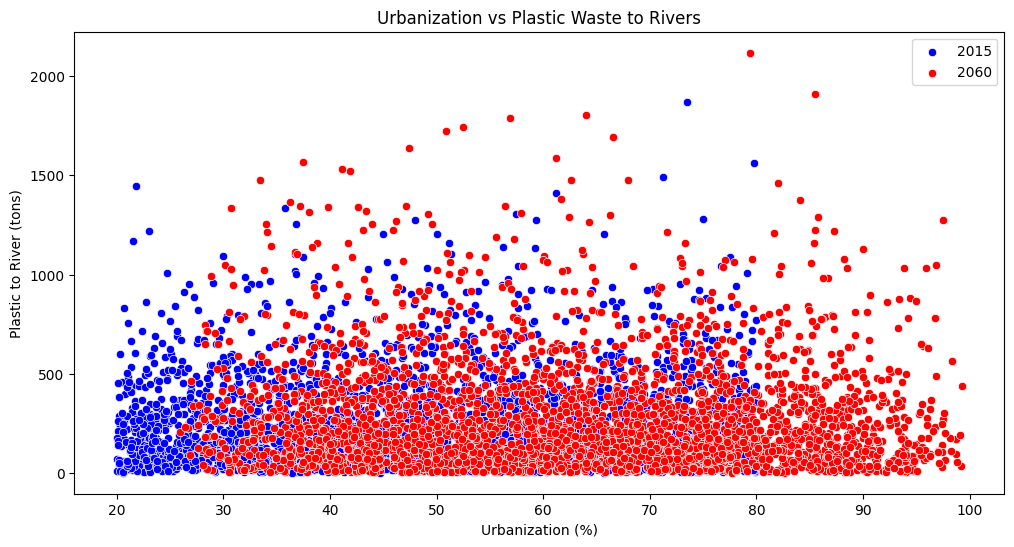

In [14]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Urbanization_2015_pct',
    y='Plastic_to_River_2015_tons',
    label='2015',
    color='blue'
)
sns.scatterplot(
    data=df,
    x='Urbanization_2060_pct',
    y='Plastic_to_River_2060_tons',
    label='2060',
    color='red'
)
plt.title('Urbanization vs Plastic Waste to Rivers')
plt.xlabel('Urbanization (%)')
plt.ylabel('Plastic to River (tons)')
plt.legend()
plt.show()


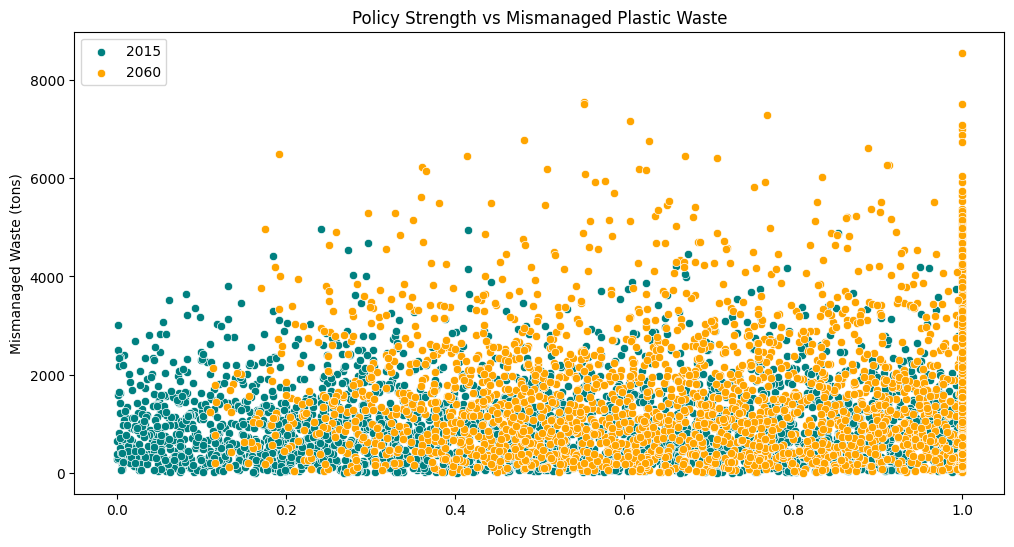

In [15]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Policy_Strength_2015',
    y='Mismanaged_Waste_2015_tons',
    data=df,
    label='2015',
    color='teal'
)
sns.scatterplot(
    x='Policy_Strength_2060',
    y='Mismanaged_Waste_2060_tons',
    data=df,
    label='2060',
    color='orange'
)
plt.title('Policy Strength vs Mismanaged Plastic Waste')
plt.xlabel('Policy Strength')
plt.ylabel('Mismanaged Waste (tons)')
plt.legend()
plt.show()


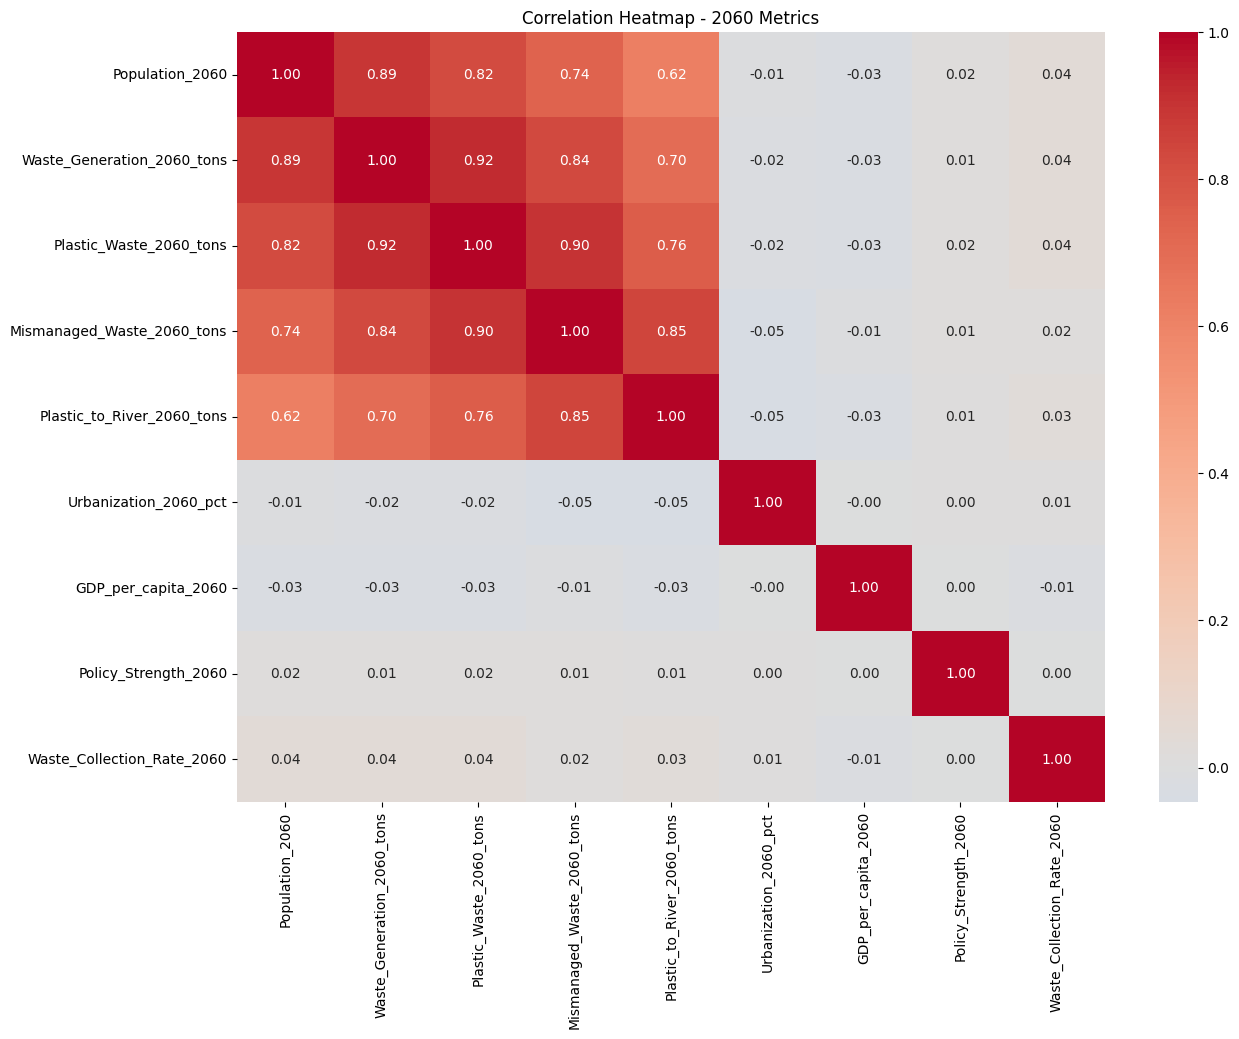

In [16]:
cols_2060 = [col for col in df.columns if '_2060' in col]
plt.figure(figsize=(14, 10))
sns.heatmap(df[cols_2060].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - 2060 Metrics')
plt.show()


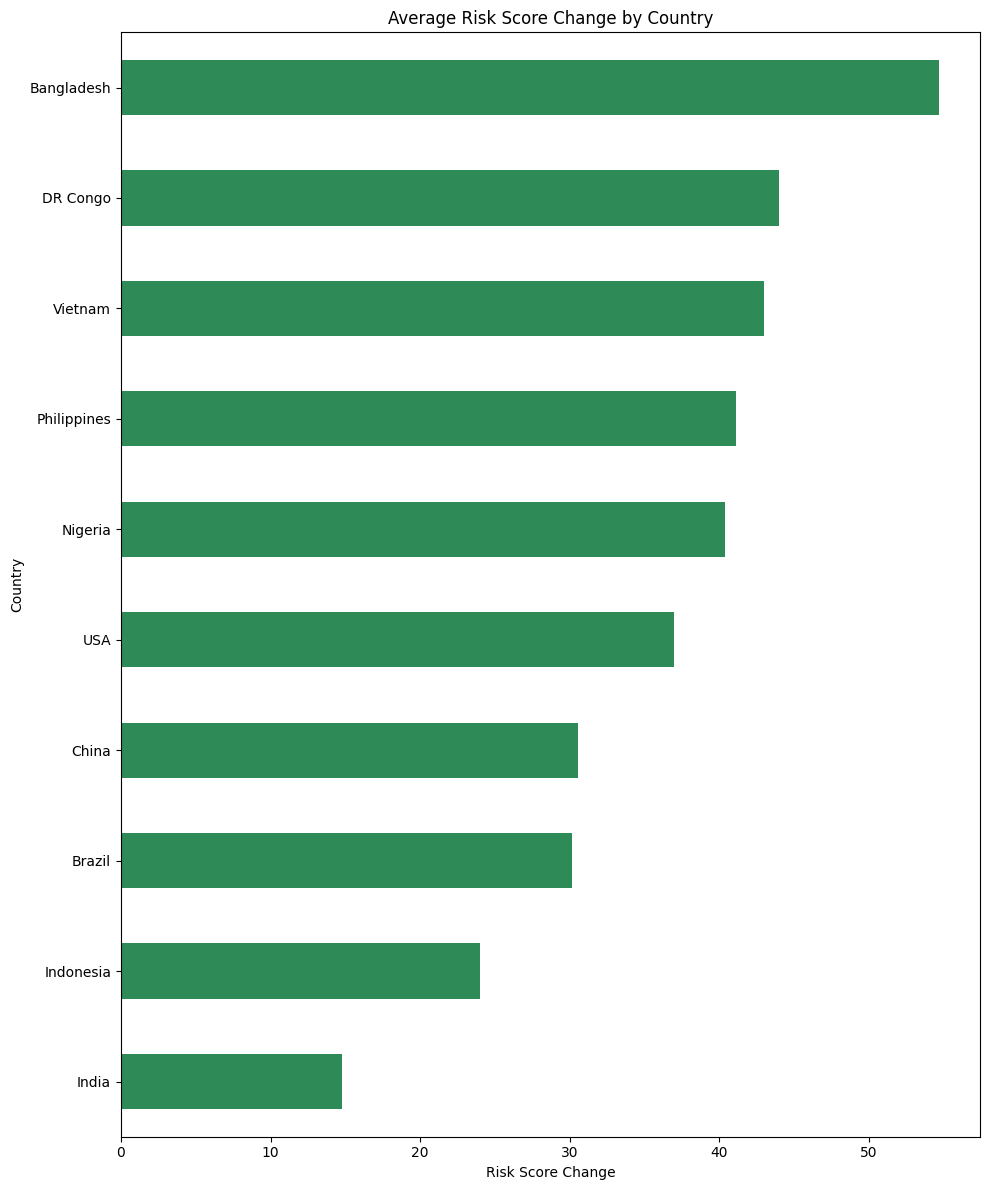

In [17]:
country_risk = df.groupby('Country')['Risk_Score_Change'].mean().sort_values()
plt.figure(figsize=(10, 12))
country_risk.plot(kind='barh', color='seagreen')
plt.title('Average Risk Score Change by Country')
plt.xlabel('Risk Score Change')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


In [19]:

threshold = df['Risk_Score_Change'].median()
df['High_Risk'] = (df['Risk_Score_Change'] > threshold).astype(int)

df_model = df.drop(['River_ID', 'River_Name', 'Risk_Score_Change'], axis=1)

for col in ['Country', 'Continent']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
X = df_model.drop('High_Risk', axis=1)
y = df_model['High_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}


🔍 Logistic Regression
Accuracy: 72.67%


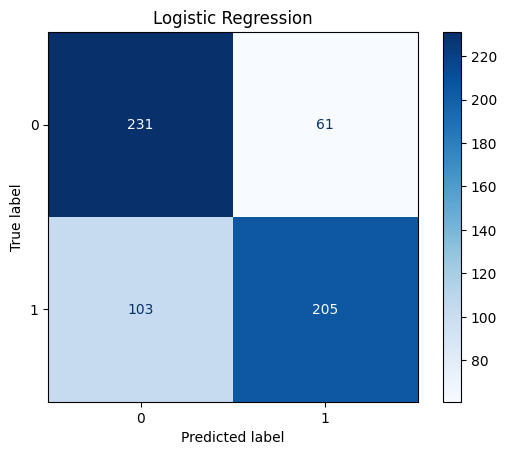


🔍 Random Forest
Accuracy: 92.83%


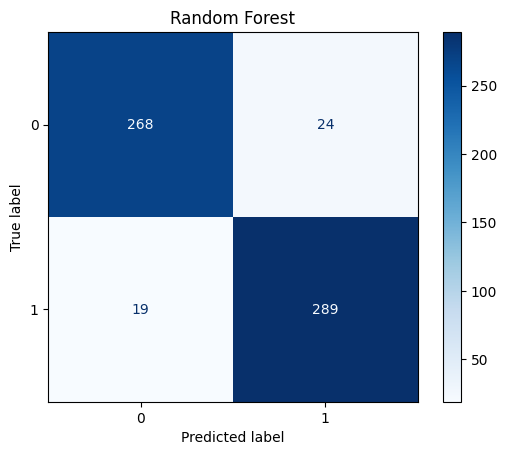


🔍 Decision Tree
Accuracy: 96.67%


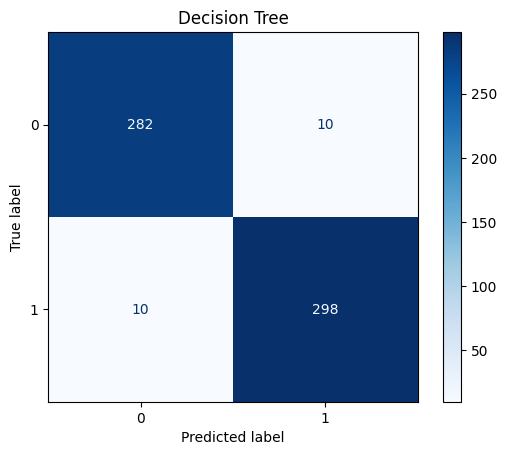


🔍 Support Vector Machine
Accuracy: 54.83%


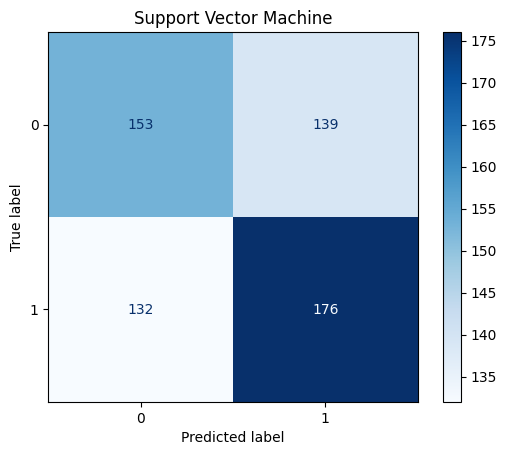


🔍 K-Nearest Neighbors
Accuracy: 51.83%


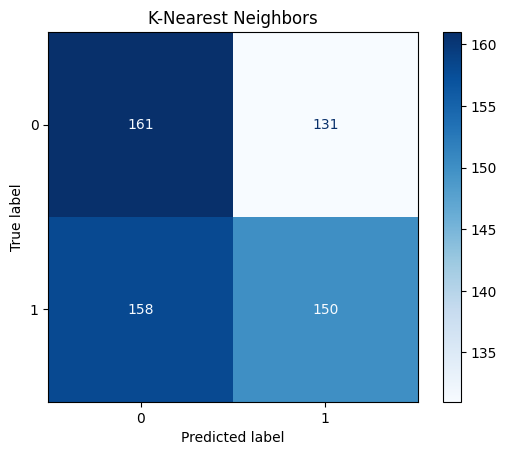


🔍 Naive Bayes
Accuracy: 68.50%


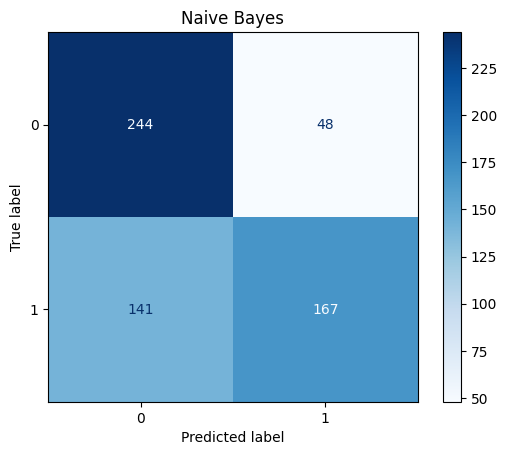

In [21]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds) * 100
    cm = confusion_matrix(y_test, preds)
    
    results[name] = acc
    
    print(f"\n🔍 {name}")
    print(f"Accuracy: {acc:.2f}%")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(name)
    plt.show()

In [22]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
print("\n📊 Model Performance Summary:")
print(results_df.sort_values(by="Accuracy (%)", ascending=False))


📊 Model Performance Summary:
                    Model  Accuracy (%)
2           Decision Tree     96.666667
1           Random Forest     92.833333
0     Logistic Regression     72.666667
5             Naive Bayes     68.500000
3  Support Vector Machine     54.833333
4     K-Nearest Neighbors     51.833333


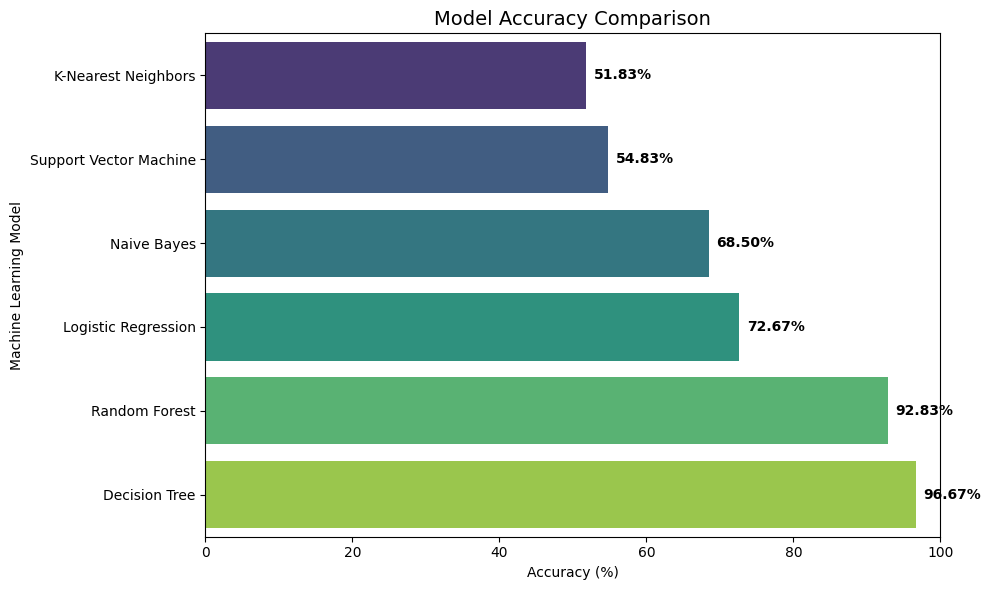

In [23]:
results_df_sorted = results_df.sort_values(by="Accuracy (%)", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df_sorted, x="Accuracy (%)", y="Model", palette="viridis")
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")
plt.xlim(0, 100)  # Full percentage scale
for i, v in enumerate(results_df_sorted["Accuracy (%)"]):
    plt.text(v + 1, i, f"{v:.2f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!